TITLE: NETWORK TRAFFIC MONITORING DASHBOARD WITH DATASET


Objective:
Here in this analysis we are going to find out about the network congestion, the factors causing the congestion and the graphical representation.

In [18]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

Data loading and inspection

In [15]:
df=pd.read_csv("C:\\Users\\Arushi\\Downloads\\embedded_system_network_security_dataset.csv")

In [ ]:
Data display

In [16]:
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   packet_size            1000 non-null   float64
 1   inter_arrival_time     1000 non-null   float64
 2   src_port               1000 non-null   int64  
 3   dst_port               1000 non-null   int64  
 4   packet_count_5s        1000 non-null   float64
 5   mean_packet_size       1000 non-null   float64
 6   spectral_entropy       1000 non-null   float64
 7   frequency_band_energy  1000 non-null   float64
 8   label                  1000 non-null   float64
 9   protocol_type_TCP      1000 non-null   bool   
 10  protocol_type_UDP      1000 non-null   bool   
 11  src_ip_192.168.1.2     1000 non-null   bool   
 12  src_ip_192.168.1.3     1000 non-null   bool   
 13  dst_ip_192.168.1.5     1000 non-null   bool   
 14  dst_ip_192.168.1.6     1000 non-null   bool   
 15  tcp_f

Missing value identification

In [5]:
df.isnull().sum()

packet_size              0
inter_arrival_time       0
src_port                 0
dst_port                 0
packet_count_5s          0
mean_packet_size         0
spectral_entropy         0
frequency_band_energy    0
label                    0
protocol_type_TCP        0
protocol_type_UDP        0
src_ip_192.168.1.2       0
src_ip_192.168.1.3       0
dst_ip_192.168.1.5       0
dst_ip_192.168.1.6       0
tcp_flags_FIN            0
tcp_flags_SYN            0
tcp_flags_SYN-ACK        0
dtype: int64

In [ ]:
Duplicate values identification

In [8]:
df.duplicated().sum()

np.int64(0)

Conclusion:
1. Rows= 1000, Columns= 18
2. No missing values, so need for handling missing values
3. No duplicated values, hence no problem of duplicacy

In [8]:
# Descriptive Statistics
df.describe()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.000000,1000.000000,1000.00000
mean,0.502446,0.512259,32024.617000,199.769000,0.506857,0.0,0.495222,0.485651,0.10000
std,0.289606,0.281130,18520.890349,180.078488,0.303271,0.0,0.292927,0.295953,0.30015
min,0.000000,0.000000,1038.000000,53.000000,0.000000,0.0,0.000000,0.000000,0.00000
25%,0.256263,0.275909,16245.250000,53.000000,0.267857,0.0,0.236912,0.228039,0.00000
50%,0.499642,0.515971,31883.000000,80.000000,0.500000,0.0,0.504290,0.467905,0.00000
75%,0.741410,0.746523,47746.250000,443.000000,0.785714,0.0,0.761556,0.750876,0.00000
max,1.000000,1.000000,65484.000000,443.000000,1.000000,0.0,1.000000,1.000000,1.00000


Here the describe() function gives the five number summary along with standard deviation, mean, and count for all the numerical columns.
Five number summary:
1. min- minimumn value of column
2. 25% - referred as Q1(lower quartile)
3. 50% - referred as Q2 or median
4. 75% - referred as Q3(upper quartile)
5. max- maximum value of column
Upper and lower quartile shows the range of max data, i.e. the maximum data lies between these.

{'whiskers': [<matplotlib.lines.Line2D at 0x1ba29c911d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1ba29c91450>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ba29c21090>],
 'medians': [<matplotlib.lines.Line2D at 0x1ba29c916d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ba29c91810>],
 'means': []}

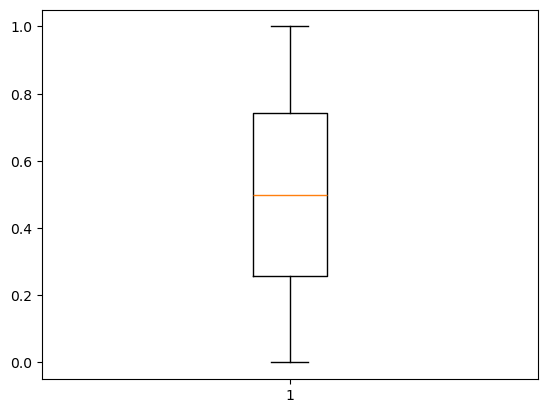

In [5]:
plt.boxplot(df["packet_size"])

In [15]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols=df.select_dtypes(include=["bool"]).columns.tolist()
print("Numerical columns:",num_cols)
print("\n")
print("Categorical columns:",cat_cols)


Numerical columns: ['packet_size', 'inter_arrival_time', 'src_port', 'dst_port', 'packet_count_5s', 'mean_packet_size', 'spectral_entropy', 'frequency_band_energy', 'label']


Categorical columns: ['protocol_type_TCP', 'protocol_type_UDP', 'src_ip_192.168.1.2', 'src_ip_192.168.1.3', 'dst_ip_192.168.1.5', 'dst_ip_192.168.1.6', 'tcp_flags_FIN', 'tcp_flags_SYN', 'tcp_flags_SYN-ACK']


Here we segregated the numerical and categorical columns in order to make the further analysis easier.

In [10]:
# Skewness analysis
np.round(df.skew(),2)

packet_size             -0.00
inter_arrival_time      -0.07
src_port                 0.06
dst_port                 0.60
packet_count_5s         -0.05
mean_packet_size         0.00
spectral_entropy        -0.00
frequency_band_energy    0.09
label                    2.67
protocol_type_TCP        0.82
protocol_type_UDP        0.61
src_ip_192.168.1.2       0.79
src_ip_192.168.1.3       0.69
dst_ip_192.168.1.5       0.69
dst_ip_192.168.1.6       0.66
tcp_flags_FIN            1.15
tcp_flags_SYN            1.25
tcp_flags_SYN-ACK        1.13
dtype: float64

In [11]:
# Kurtosis analysis
np.round(df.kurtosis(),2)

packet_size             -1.20
inter_arrival_time      -1.15
src_port                -1.17
dst_port                -1.62
packet_count_5s         -1.19
mean_packet_size         0.00
spectral_entropy        -1.26
frequency_band_energy   -1.23
label                    5.14
protocol_type_TCP       -1.33
protocol_type_UDP       -1.63
src_ip_192.168.1.2      -1.37
src_ip_192.168.1.3      -1.53
dst_ip_192.168.1.5      -1.53
dst_ip_192.168.1.6      -1.56
tcp_flags_FIN           -0.68
tcp_flags_SYN           -0.43
tcp_flags_SYN-ACK       -0.73
dtype: float64

In [48]:
# dropping the column as it contains all values as 0
df=df.drop("mean_packet_size",axis=1)

Now using my prior knowledge of telecommunication networks, I concluded the importance of features present in the dataset for calculating the congestion.
Most important features are:
1. packet_size
2. inter_arrival_time
3. spectral_entropy
4. packet_count_5s

In [16]:
df=df.drop("Traffric_Rate",axis=1)

In [19]:
# TRAFFIC LOAD and TRAFFIC RATE new features are created using feature engineering
df["Traffic_Rate"]=df["packet_count_5s"]/5

In [20]:
df["Traffic_Load"]=df["packet_count_5s"]*df["packet_size"]

In [17]:
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,...,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK,Traffic_Load,CI,Congestion_level,high_congestion,group,duration,Traffic_Rate
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,...,False,False,False,0.347275,0.454342,MODERATE,False,1,NaN,0.171429
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,...,False,True,False,0.414511,0.314308,MODERATE,False,1,NaN,0.157143
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,...,False,False,False,0.064628,0.357818,MODERATE,False,1,0.268745,0.057143
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,...,False,False,False,0.081910,0.236310,LOW,False,1,NaN,0.028571
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,...,False,True,False,0.465283,0.450803,MODERATE,False,1,0.312725,0.142857


In [21]:
# CI refers to the congestion index 
df["CI"]=0.5*df["Traffic_Load"]+0.3 * (1 - df['inter_arrival_time'])+ 0.2* df["spectral_entropy"]

In [18]:
cols_disp=["packet_size","inter_arrival_time","packet_count_5s","spectral_entropy","Traffic_Rate","CI","Congestion_level","Traffic_Load"]
df[cols_disp].head()

,packet_size,inter_arrival_time,packet_count_5s,spectral_entropy,Traffic_Rate,CI,Congestion_level,Traffic_Load
0,0.405154,0.620362,0.857143,0.834066,0.171429,0.454342,MODERATE,0.347275
1,0.527559,0.741288,0.785714,0.147196,0.157143,0.314308,MODERATE,0.414511
2,0.226199,0.485116,0.285714,0.855192,0.057143,0.357818,MODERATE,0.064628
3,0.573372,0.450965,0.142857,0.153220,0.028571,0.236310,LOW,0.081910
4,0.651396,0.888740,0.714286,0.923916,0.142857,0.450803,MODERATE,0.465283


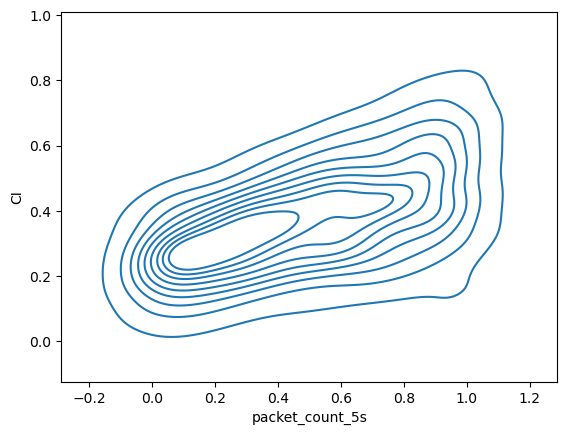

In [13]:
sb.kdeplot(data=df,x="packet_count_5s",y="CI")
plt.show()

Interpretation:
1. The innermost ring (around x=0.1, y=0.2) is the "peak." Most of my data points are concentrated in this low-value region.
2. The upward diagonal shape shows a positive correlation; as packet_count_5s grows, CI usually grows with it.
3. The plot is wider at the top-right than the bottom-left, meaning there is more variance (less predictability) at higher packet counts.
4. The area outside the largest, outermost ring contains your most unusual or rare data combinations.

In [25]:
def label_congestion(ci):
    if ci < 0.3:
        return "LOW"  
    elif ci < 0.6:
        return " MODERATE"  
    else:
        return "HIGH"  

df['Congestion_level'] = df['CI'].apply(label_congestion)

The Congestion Index integrates traffic intensity, temporal dynamics, and traffic variability. A derived feature, traffic_load, was introduced to better represent actual network utilization. 


In [9]:
df['high_congestion'] = df['CI'] > 0.6
df['group'] = (df['high_congestion'] != df['high_congestion'].shift()).cumsum()
df["duration"] = df[df['high_congestion']].groupby('group')['inter_arrival_time'].sum()


Here due to the absence of explicit timestamp in dataset the real-time duration was difficult to be calculated.
However the duartion was approximated using cumulative inter_arrival_time, which represent the temporal spacing between packets.

In [74]:
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,...,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK,Traffric_Rate,CI,Traffic_Load,Congestion_level,high_congestion,group,duration
0,0.405154,0.620362,62569,443,0.857143,0.834066,0.534891,0.0,False,True,...,False,False,False,0.171429,0.454342,0.347275,MODERATE,False,1,NaN
1,0.527559,0.741288,59382,443,0.785714,0.147196,0.990757,0.0,False,True,...,False,True,False,0.157143,0.314308,0.414511,MODERATE,False,1,NaN
2,0.226199,0.485116,65484,80,0.285714,0.855192,0.031781,0.0,False,True,...,False,False,False,0.057143,0.357818,0.064628,MODERATE,False,1,0.268745
3,0.573372,0.450965,51707,53,0.142857,0.153220,0.169958,0.0,False,False,...,False,False,False,0.028571,0.236310,0.081910,LOW,False,1,NaN
4,0.651396,0.888740,26915,53,0.714286,0.923916,0.552053,0.0,True,False,...,False,True,False,0.142857,0.450803,0.465283,MODERATE,False,1,0.312725


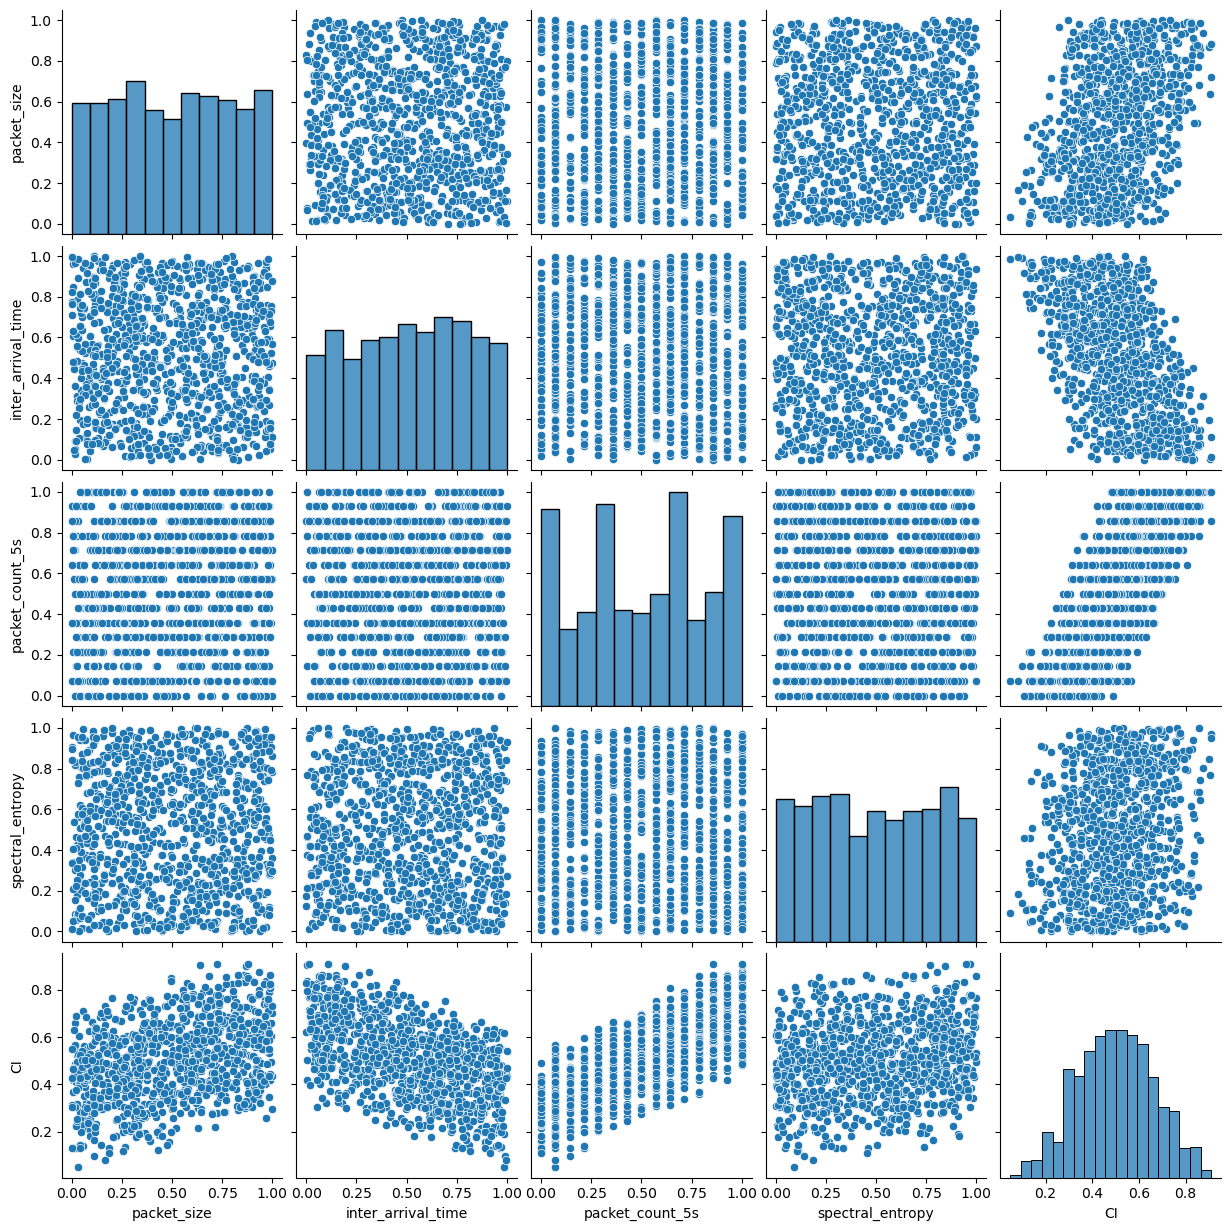

In [35]:
cols = [ 'packet_size','inter_arrival_time','packet_count_5s','spectral_entropy','CI']
sb.pairplot(df[cols])

From the above pairplot we can draw certain conclusions as follows:
1. Postive relation between packet_count_5s and CI, justifying the higher weight given to it in calculation
2. Negative realation between inter_arrival_time and CI, therfore back in the calculation we used (1-inter_arrival_time).
3. Spectral_entropy has a weak relation with CI, thus indicating that more randomness would reflect more congestion , and hence had the
    least weightage in calculation

In [26]:
dist = df['Congestion_level'].value_counts().reset_index()
dist.columns = ['Congestion Level', 'Record Count']
df = df.dropna(subset=['Congestion_level'])
dist['Percentage'] = (dist['Record Count'] / len(df) * 100).round(1).astype(str) + '%'

# Custom order
order = ['LOW', ' MODERATE', 'HIGH']
dist['Congestion Level'] = pd.Categorical(dist['Congestion Level'], categories=order, ordered=True)

dist = dist.sort_values('Congestion Level')

print(dist.to_string(index=False))

Congestion Level  Record Count Percentage
             LOW           346      34.6%
        MODERATE           566      56.6%
            HIGH            88       8.8%


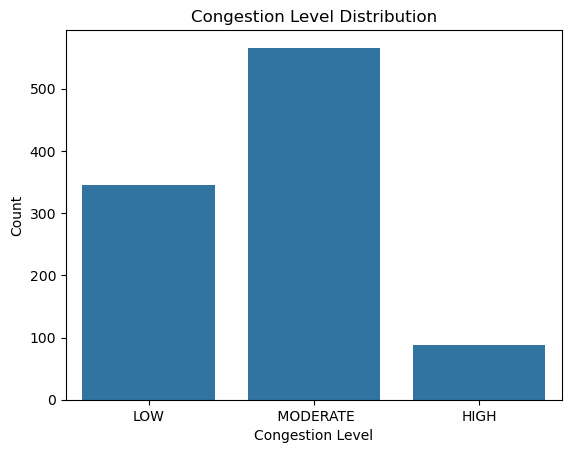

In [21]:
sb.countplot(x='Congestion_level', data=df, order=order)
plt.title("Congestion Level Distribution")
plt.xlabel("Congestion Level")
plt.ylabel("Count")
plt.show()

# Accuracy calculation

In [22]:
from scipy.stats import pearsonr

features = ['packet_size',
            'inter_arrival_time',
            'spectral_entropy',
            'packet_count_5s']

for col in features:
    corr, p = pearsonr(df[col], df['CI'])

    print(f"\nFeature: {col}")
    print("Correlation:", round(corr,3))
    print("P-value:", p)


Feature: packet_size
Correlation: 0.483
P-value: 1.4873397655408756e-59

Feature: inter_arrival_time
Correlation: -0.556
P-value: 3.517907216276475e-82

Feature: spectral_entropy
Correlation: 0.376
P-value: 5.605790051801615e-35

Feature: packet_count_5s
Correlation: 0.509
P-value: 3.683084541112422e-67


Here p-values,
1. packet_size: p-value indicates statistically significant relation
2. inter_arrival_time: p-value indicates highly significant relation
3. spectral_entropy:p-value indicates statically significant relation
4. packet_count_5s: p-value indicates strong statistical relation

In [29]:
group_check = df.groupby('Congestion_level')['CI'].mean()

print(group_check)

Congestion_level
 MODERATE    0.425095
HIGH         0.680959
LOW          0.213536
Name: CI, dtype: float64


Interpretation:
The average Congestion Index increases progressively from LOW to MODERATE and HIGH congestion categories. 
This validates that the proposed Congestion Index effectively distinguishes between different congestion levels. 
The observed trend confirms the logical consistency and reliability of the congestion classification approach.

The CI calculated here has:
1.proper ordering
2.meaningful separation
3.logical scaling
So the weighted formula you used is not random noise — it captures congestion behavior reasonably well.



CONCLUSION:
I started with the problem of "Congestion in network traffic", and here after this analysis I was able to calculate the congestion in the form of Congestion Index which is further classified as LOW, MODERATE and,HIGH.
I also tried calculating the Congestion duration however we constrained due to the absence of timestamp in dataset.
I hereby conclude by showing the count and percentage of congestion level, supported by a barplot.
Accuracy of my analysis and the statistical validation is also done above with interpretataion.